<a href="https://colab.research.google.com/github/moiseshancco-png/SUPERVISION-N-283-2015-OS-CD/blob/main/SUPERVISION_N%C2%B0_RCD_283_2015.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== INGRESO DE DATOS DEL EXPEDIENTE ===
Ingrese la cantidad de estratos/diámetros (ej. 2, 3, etc.): 2

--- Estrato 1 ---
Ingrese el diámetro de la tubería [en mm]: 32
Ingrese la longitud construida para 32 mm [en m]: 700

--- Estrato 2 ---
Ingrese el diámetro de la tubería [en mm]: 64
Ingrese la longitud construida para 64 mm [en m]: 3000


=== DISTRIBUCIÓN POR ESTRATOS (AFIJACIÓN PROPORCIONAL) ===
Diámetro     | Población (N_h)    | Peso (W_h)   | A Supervisar (n_h)   | % del Total
-------------------------------------------------------------------------------------
32 mm        | 700.00 m           | 0.1892       | 47.71 m              | 1.29 %
64 mm        | 3,000.00 m         | 0.8108       | 204.45 m             | 5.53 %
-------------------------------------------------------------------------------------

=== RESUMEN FINAL DEL EXPEDIENTE ===
Total de metros del proyecto (N):  3,700.00 m
Total físico a supervisar (n):     252.16 m
Porcentaje a auditar:              6.82 %



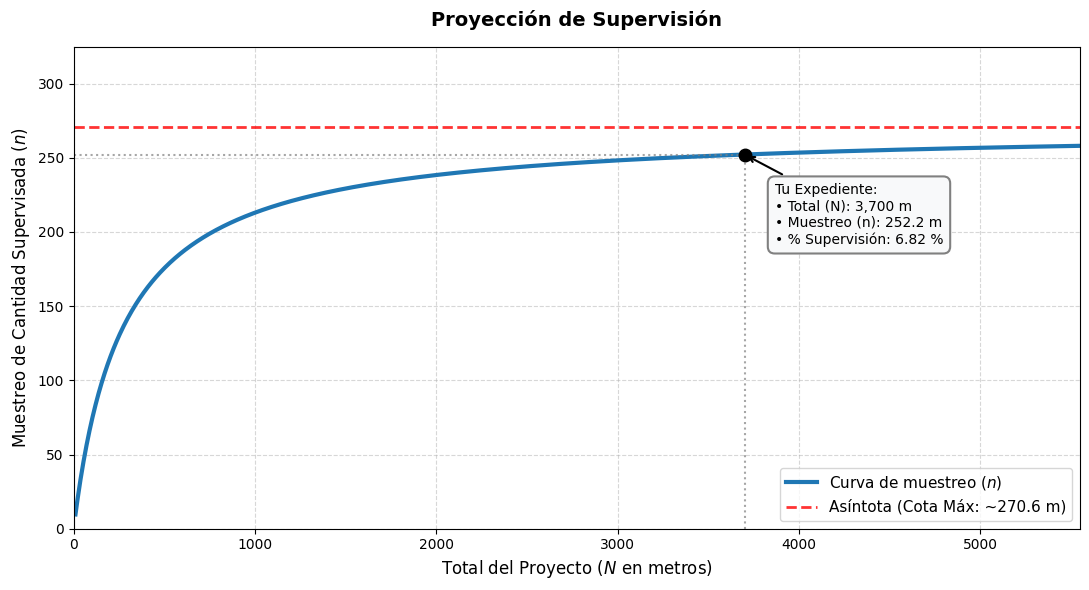

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def evaluar_expediente_dinamico():
    # 1. Constantes normativas (RCD 283-2015-OS/CD)
    t_alpha = 1.645
    d = 0.05
    S2h = 0.25  # Varianza máxima asumida
    C = (t_alpha**2) * S2h
    asintota_max = C / (d**2)

    # ==========================================
    # 2. INGRESO DINÁMICO DE DATOS
    # ==========================================
    print("=== INGRESO DE DATOS DEL EXPEDIENTE ===")
    while True:
        try:
            num_estratos = int(input("Ingrese la cantidad de estratos/diámetros (ej. 2, 3, etc.): "))
            if num_estratos > 0:
                break
            print("Por favor, ingrese un número entero mayor a 0.")
        except ValueError:
            print("Entrada inválida. Ingrese un número entero.")

    datos_estratos = {}
    tope_de_obra_m = 0.0

    for i in range(num_estratos):
        print(f"\n--- Estrato {i+1} ---")
        diametro = input("Ingrese el diámetro de la tubería [en mm]: ")
        # Validamos que se ingrese un número para los metros
        while True:
            try:
                metros = float(input(f"Ingrese la longitud construida para {diametro} mm [en m]: "))
                if metros >= 0:
                    break
                print("La longitud no puede ser negativa.")
            except ValueError:
                print("Por favor, ingrese un número válido.")

        datos_estratos[diametro] = metros
        tope_de_obra_m += metros

    if tope_de_obra_m <= 0:
        print("\nError: El total proyectado de la obra debe ser mayor a 0 metros.")
        return

    # ==========================================
    # 3. CÁLCULOS MATEMÁTICOS
    # ==========================================
    # Muestra total y porcentaje fijo
    n_supervisar = C / ((d**2) + (C / tope_de_obra_m))
    porcentaje_fijo = (n_supervisar / tope_de_obra_m) * 100

    # ==========================================
    # 4. REPORTE EN CONSOLA (DISTRIBUCIÓN Y RESUMEN)
    # ==========================================
    print("\n\n=== DISTRIBUCIÓN POR ESTRATOS (AFIJACIÓN PROPORCIONAL) ===")
    print(f"{'Diámetro':<12} | {'Población (N_h)':<18} | {'Peso (W_h)':<12} | {'A Supervisar (n_h)':<20} | {'% del Total'}")
    print("-" * 85)

    for diametro, metros in datos_estratos.items():
        Wh = metros / tope_de_obra_m if tope_de_obra_m > 0 else 0
        nh = n_supervisar * Wh
        porcentaje_nh = (nh / tope_de_obra_m) * 100

        # Formateo de las columnas
        col_diam = f"{diametro} mm".ljust(12)
        col_pob = f"{metros:,.2f} m".ljust(18)
        col_peso = f"{Wh:.4f}".ljust(12)
        col_super = f"{nh:,.2f} m".ljust(20)
        col_porc = f"{porcentaje_nh:.2f} %"
        print(f"{col_diam} | {col_pob} | {col_peso} | {col_super} | {col_porc}")

    print("-" * 85)

    # Resumen final solicitado
    print("\n=== RESUMEN FINAL DEL EXPEDIENTE ===")
    print(f"Total de metros del proyecto (N):  {tope_de_obra_m:,.2f} m")
    print(f"Total físico a supervisar (n):     {n_supervisar:,.2f} m")
    print(f"Porcentaje a auditar:              {porcentaje_fijo:.2f} %\n")

    # ==========================================
    # 5. GRÁFICA ASINTÓTICA
    # ==========================================
    # Extendemos el eje X a 15km o más para garantizar que la asíntota se vea claramente
    x_max_grafica = max(tope_de_obra_m, tope_de_obra_m * 1.5)
    N_valores = np.linspace(10, x_max_grafica, 1000)
    n_valores = C / ((d**2) + (C / N_valores))

    plt.figure(figsize=(11, 6))

    # Curva de cálculo
    plt.plot(N_valores, n_valores, color='#1f77b4', linewidth=3, label='Curva de muestreo ($n$)')

    # Asíntota (Techo normativo)
    plt.axhline(y=asintota_max, color='red', linestyle='--', linewidth=2, alpha=0.8,
                label=f'Asíntota (Cota Máx: ~{asintota_max:.1f} m)')

    # Punto específico de tu proyecto
    plt.plot(tope_de_obra_m, n_supervisar, marker='o', markersize=9, color='black', zorder=5)

    # Líneas punteadas guía para el punto
    plt.vlines(x=tope_de_obra_m, ymin=0, ymax=n_supervisar, color='gray', linestyle=':', alpha=0.7)
    plt.hlines(y=n_supervisar, xmin=0, xmax=tope_de_obra_m, color='gray', linestyle=':', alpha=0.7)

    # Caja de texto explicativa apuntando al proyecto
    texto_punto = (
        f'Tu Expediente:\n'
        f'• Total (N): {tope_de_obra_m:,.0f} m\n'
        f'• Muestreo (n): {n_supervisar:.1f} m\n'
        f'• % Supervisión: {porcentaje_fijo:.2f} %'
    )

    # Ajuste para que la caja de texto no se salga de la imagen
    offset_x = -0.15 if tope_de_obra_m > (x_max_grafica * 0.7) else 0.03

    plt.annotate(texto_punto,
                 xy=(tope_de_obra_m, n_supervisar),
                 xytext=(tope_de_obra_m + (x_max_grafica * offset_x), n_supervisar - 60),
                 bbox=dict(boxstyle="round,pad=0.5", fc="#f8f9fa", ec="gray", lw=1.5),
                 arrowprops=dict(arrowstyle="->", connectionstyle="arc3", color='black', lw=1.5),
                 fontsize=10)

    # Formato visual del gráfico
    plt.title('Proyección de Supervisión', fontsize=14, pad=15, fontweight='bold')
    plt.xlabel('Total del Proyecto ($N$ en metros)', fontsize=12)
    plt.ylabel('Muestreo de Cantidad Supervisada ($n$)', fontsize=12)

    # Fijar límites para asegurar que empiece en 0 y no se corte
    plt.xlim(0, x_max_grafica)
    plt.ylim(0, asintota_max * 1.2)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='lower right', fontsize=11)

    plt.tight_layout()
    plt.show()

# Ejecutar el programa interactivo
evaluar_expediente_dinamico()